In [1]:
from bs4 import BeautifulSoup
import requests
import pandas as pd
import numpy as np
import time

# Amazon category mapping
categories = {
    "Electronics": "electronics",
    "Computers&Accessories": "computers",
    "Home&Kitchen": "kitchen",
    "OfficeProducts": "office-products",
    "MusicalInstruments": "mi",
    "HomeImprovement": "hi",
    "Toys&Games": "toys",
    "Car&Motorbike": "automotive",
    "Health&PersonalCare": "hpc"
}

# Lists
product_name = []
price = []
rating = []
reviews = []
product_link = []
category_list = []
page_number = []

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0 Safari/537.36",
    "Accept-Language": "en-US,en;q=0.9"
}

total_time = time.time()

# Loop through categories
for category_name, category_id in categories.items():

    print(f"\nScraping Category: {category_name}")

    # Loop through pages
    for page in range(1, 6):

        start_time = time.time()

        # Amazon category URL
        url = f"https://www.amazon.in/s?i={category_id}&page={page}"

        response = requests.get(url, headers=headers)

        soup = BeautifulSoup(response.content, "html.parser")

        # Product containers
        products = soup.find_all("div", {"data-component-type": "s-search-result"})

        # Loop products
        for item in products:

            # Product Name
            name = item.h2.text.strip() if item.h2 else np.nan

            # Price
            whole_price = item.find("span", class_="a-price-whole")
            fraction_price = item.find("span", class_="a-price-fraction")

            if whole_price:
                product_price = whole_price.text.replace(",", "")

                if fraction_price:
                    product_price += fraction_price.text
            else:
                product_price = np.nan

            # Rating
            rating_tag = item.find("span", class_="a-icon-alt")
            product_rating = rating_tag.text if rating_tag else np.nan

            # Reviews
            review_tag = item.find("span", class_="a-size-base s-underline-text")
            product_reviews = review_tag.text if review_tag else np.nan

            # Product Link
            link_tag = item.find("a", class_="a-link-normal s-no-outline")

            if link_tag:
                link = "https://www.amazon.in" + link_tag.get("href")
            else:
                link = np.nan

            # Append data
            product_name.append(name)
            price.append(product_price)
            rating.append(product_rating)
            reviews.append(product_reviews)
            product_link.append(link)
            category_list.append(category_name)
            page_number.append(page)

        print(f"{category_name} | Page {page} completed in {time.time() - start_time:.2f} sec")

        # Delay to avoid blocking
        time.sleep(2)

print("\nTotal Time:", time.time() - total_time)

# Create DataFrame
df = pd.DataFrame({
    "Category": category_list,
    "Product Name": product_name,
    "Price": price,
    "Rating": rating,
    "Reviews": reviews,
    "Product Link": product_link,
    "Page Number": page_number
})

# Save CSV
df.to_csv("amazon_category_products.csv", index=False)

# Show first rows
print(df.head())


Scraping Category: Electronics
Electronics | Page 1 completed in 0.87 sec
Electronics | Page 2 completed in 2.81 sec
Electronics | Page 3 completed in 2.15 sec
Electronics | Page 4 completed in 2.46 sec
Electronics | Page 5 completed in 2.42 sec

Scraping Category: Computers&Accessories
Computers&Accessories | Page 1 completed in 0.66 sec
Computers&Accessories | Page 2 completed in 2.45 sec
Computers&Accessories | Page 3 completed in 2.17 sec
Computers&Accessories | Page 4 completed in 2.02 sec
Computers&Accessories | Page 5 completed in 1.89 sec

Scraping Category: Home&Kitchen
Home&Kitchen | Page 1 completed in 0.67 sec
Home&Kitchen | Page 2 completed in 2.61 sec
Home&Kitchen | Page 3 completed in 1.95 sec
Home&Kitchen | Page 4 completed in 2.00 sec
Home&Kitchen | Page 5 completed in 2.29 sec

Scraping Category: OfficeProducts
OfficeProducts | Page 1 completed in 0.56 sec
OfficeProducts | Page 2 completed in 2.58 sec
OfficeProducts | Page 3 completed in 2.20 sec
OfficeProducts | Pag

In [ ]:
#  DATA COLLECTION & WEB SCRAOING

In [2]:
df

,Category,Product Name,Price,Rating,Reviews,Product Link,Page Number
0,Electronics,"OTEK Epic FHD Projector (Non-Smart, No WiFi), ...",8999,3.4 out of 5 stars,NaN,https://www.amazon.in/sspa/click?ie=UTF8&spc=M...,2
1,Electronics,"E Gate Atom 4X Air, Fully Automatic, True 200 ...",6650,4.2 out of 5 stars,NaN,https://www.amazon.in/sspa/click?ie=UTF8&spc=M...,2
2,Electronics,WZATCO Yuva Go Pro Fully Automatic Native 1080...,10990,4.4 out of 5 stars,NaN,https://www.amazon.in/sspa/click?ie=UTF8&spc=M...,2
3,Electronics,"Samsung Galaxy M07 Mobile (Black, 4GB RAM, 64G...",9499,4.2 out of 5 stars,NaN,https://www.amazon.in/Samsung-Storage-MediaTek...,2
4,Electronics,"Lava Bold 2 5G (Midnight Black, 6 GB RAM, 128 ...",13999,4.0 out of 5 stars,NaN,https://www.amazon.in/Lava-Midnight-Storage-Pr...,2
...,...,...,...,...,...,...,...
826,Health&PersonalCare,Carbamide Forte Cod Liver Oil Capsules Omega 3...,261,4.1 out of 5 stars,NaN,https://www.amazon.in/Carbamide-Forte-Capsules...,5
827,Health&PersonalCare,Medmanor Acnerex facewash | 125ml,473,4.7 out of 5 stars,NaN,https://www.amazon.in/ACNEREX-ADVANCE-FACEWASH...,5
828,Health&PersonalCare,Jeena Sikho Swaranfalam Amrit Sea Buckthorn Be...,1107,4.6 out of 5 stars,NaN,https://www.amazon.in/Jeena-Sikho-Swaranfalam-...,5
829,Health&PersonalCare,RIYANSH Amrit Juice 500 ml,1725,4.2 out of 5 stars,NaN,https://www.amazon.in/RIYANSH-Amrit-Juice-500-...,5


In [25]:
df=pd.read_csv("amazon_category_products.csv")
df

,Category,Product Name,Price,Rating,Reviews,Product Link,Page Number
0,Electronics,"OTEK Epic FHD Projector (Non-Smart, No WiFi), ...",8999.0,3.4 out of 5 stars,NaN,https://www.amazon.in/sspa/click?ie=UTF8&spc=M...,2
1,Electronics,"E Gate Atom 4X Air, Fully Automatic, True 200 ...",6650.0,4.2 out of 5 stars,NaN,https://www.amazon.in/sspa/click?ie=UTF8&spc=M...,2
2,Electronics,WZATCO Yuva Go Pro Fully Automatic Native 1080...,10990.0,4.4 out of 5 stars,NaN,https://www.amazon.in/sspa/click?ie=UTF8&spc=M...,2
3,Electronics,"Samsung Galaxy M07 Mobile (Black, 4GB RAM, 64G...",9499.0,4.2 out of 5 stars,NaN,https://www.amazon.in/Samsung-Storage-MediaTek...,2
4,Electronics,"Lava Bold 2 5G (Midnight Black, 6 GB RAM, 128 ...",13999.0,4.0 out of 5 stars,NaN,https://www.amazon.in/Lava-Midnight-Storage-Pr...,2
...,...,...,...,...,...,...,...
826,Health&PersonalCare,Carbamide Forte Cod Liver Oil Capsules Omega 3...,261.0,4.1 out of 5 stars,NaN,https://www.amazon.in/Carbamide-Forte-Capsules...,5
827,Health&PersonalCare,Medmanor Acnerex facewash | 125ml,473.0,4.7 out of 5 stars,NaN,https://www.amazon.in/ACNEREX-ADVANCE-FACEWASH...,5
828,Health&PersonalCare,Jeena Sikho Swaranfalam Amrit Sea Buckthorn Be...,1107.0,4.6 out of 5 stars,NaN,https://www.amazon.in/Jeena-Sikho-Swaranfalam-...,5
829,Health&PersonalCare,RIYANSH Amrit Juice 500 ml,1725.0,4.2 out of 5 stars,NaN,https://www.amazon.in/RIYANSH-Amrit-Juice-500-...,5


In [ ]:
# BASIC INFORMATION

In [3]:
df.head()

,Category,Product Name,Price,Rating,Reviews,Product Link,Page Number
0,Electronics,"OTEK Epic FHD Projector (Non-Smart, No WiFi), ...",8999,3.4 out of 5 stars,NaN,https://www.amazon.in/sspa/click?ie=UTF8&spc=M...,2
1,Electronics,"E Gate Atom 4X Air, Fully Automatic, True 200 ...",6650,4.2 out of 5 stars,NaN,https://www.amazon.in/sspa/click?ie=UTF8&spc=M...,2
2,Electronics,WZATCO Yuva Go Pro Fully Automatic Native 1080...,10990,4.4 out of 5 stars,NaN,https://www.amazon.in/sspa/click?ie=UTF8&spc=M...,2
3,Electronics,"Samsung Galaxy M07 Mobile (Black, 4GB RAM, 64G...",9499,4.2 out of 5 stars,NaN,https://www.amazon.in/Samsung-Storage-MediaTek...,2
4,Electronics,"Lava Bold 2 5G (Midnight Black, 6 GB RAM, 128 ...",13999,4.0 out of 5 stars,NaN,https://www.amazon.in/Lava-Midnight-Storage-Pr...,2


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 831 entries, 0 to 830
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Category      831 non-null    object 
 1   Product Name  831 non-null    object 
 2   Price         826 non-null    object 
 3   Rating        793 non-null    object 
 4   Reviews       0 non-null      float64
 5   Product Link  831 non-null    object 
 6   Page Number   831 non-null    int64  
dtypes: float64(1), int64(1), object(5)
memory usage: 45.6+ KB


In [5]:
df.columns

Index(['Category', 'Product Name', 'Price', 'Rating', 'Reviews',
       'Product Link', 'Page Number'],
      dtype='object')

In [6]:
df.shape

(831, 7)

In [ ]:
# MISSING VALUES & DATA CLEANING

In [134]:
print(df.isnull().sum())

Category          0
Product Name      0
Price             0
Rating            0
Reviews         831
dtype: int64


In [135]:
print(df["Reviews"].isna().sum()) 

831


In [136]:
print(df["Reviews"].unique())

[nan]


In [141]:
# Check if mode exists before filling
if not df["Reviews"].mode().empty:
    df["Reviews"] = df["Reviews"].fillna(df["Reviews"].mode()[0])
else:
    # Fallback if no mode is available
    df["Reviews"] = df["Reviews"].fillna("Unknown")


In [142]:
print(df.isnull().sum())

Category        0
Product Name    0
Price           0
Rating          0
Reviews         0
dtype: int64


In [ ]:
# DUPLICATE VALUES

In [148]:
df.duplicated().sum()

19

In [150]:
df.drop_duplicates(inplace=True)

In [151]:
df.duplicated().sum()

0

In [175]:

print(df.columns)

Index(['Category', 'Product Name', 'Price', 'Rating', 'Reviews'], dtype='object')


In [154]:
category_products = (df.groupby('Category')['Product Name'].count().sort_values(ascending=False))
print(category_products)

Category
Electronics              113
OfficeProducts           108
Car&Motorbike            105
Computers&Accessories    105
Home&Kitchen              96
MusicalInstruments        96
Toys&Games                95
Health&PersonalCare       94
Name: Product Name, dtype: int64


In [49]:
# Clean Price Column

df["Price"] = df["Price"].astype(str)

df["Price"] = df["Price"].str.replace(",", "")

df["Price"] = pd.to_numeric(
    df["Price"],
    errors="coerce"
)

In [95]:
avg_rating = df.groupby("Category")["Rating"].mean()

In [93]:
# Clean Ratings Column


df["Rating"] = df["Rating"].astype(str)

df["Rating"] = df["Rating"].str.extract(r'(\d+\.\d+)')

df["Rating"] = pd.to_numeric(
    df["Rating"],
    errors="coerce"
)

In [73]:
df.dropna(subset=["Category", "Rating"], inplace=True)

In [74]:
df.dropna(inplace=True)

In [78]:
# Select Top Categories Only

top_categories = df["Category"].value_counts().head(10).index

print(top_categories)

Index(['Electronics', 'Fashion', 'Home', 'Books', 'Toys'], dtype='object', name='Category')


In [79]:
# Filter Dataset

filtered_df = df[
    df["Category"].isin(top_categories)
]

In [80]:
filtered_df.head()

,Category,Rating,Reviews,Price
0,Electronics,4.3,500,1200
1,Fashion,4.0,300,800
2,Home,3.5,200,600
3,Books,4.6,800,400
4,Toys,3.8,400,500


In [83]:
filtered_df.shape

(5, 4)

In [86]:
filtered_df["Category"].unique()

array(['Electronics', 'Fashion', 'Home', 'Books', 'Toys'], dtype=object)

In [ ]:
# DATA VISUALIZATION
1.UNIVARIATE
2.BIVARIATE ANALYSIS

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [67]:
print(df.columns)

Index(['Category', 'Rating', 'Reviews', 'Price'], dtype='object')


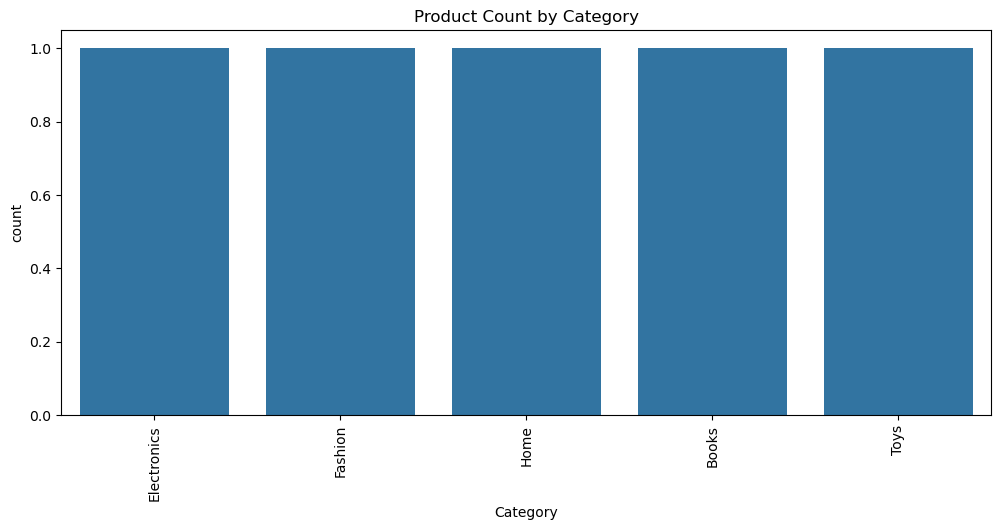

In [56]:
# Count Plot
# Category vs Product Count

plt.figure(figsize=(12,5))

sns.countplot(x=df["Category"])

plt.xticks(rotation=90)

plt.title("Product Count by Category")

plt.show()

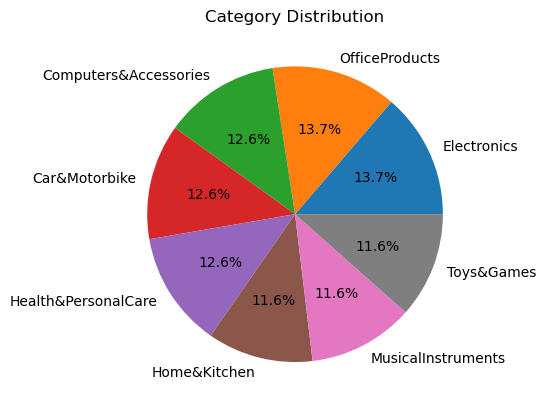

In [19]:
#Pie Chart

df["Category"].value_counts().plot.pie(
    autopct="%1.1f%%"
)

plt.title("Category Distribution")

plt.ylabel("")

plt.show()

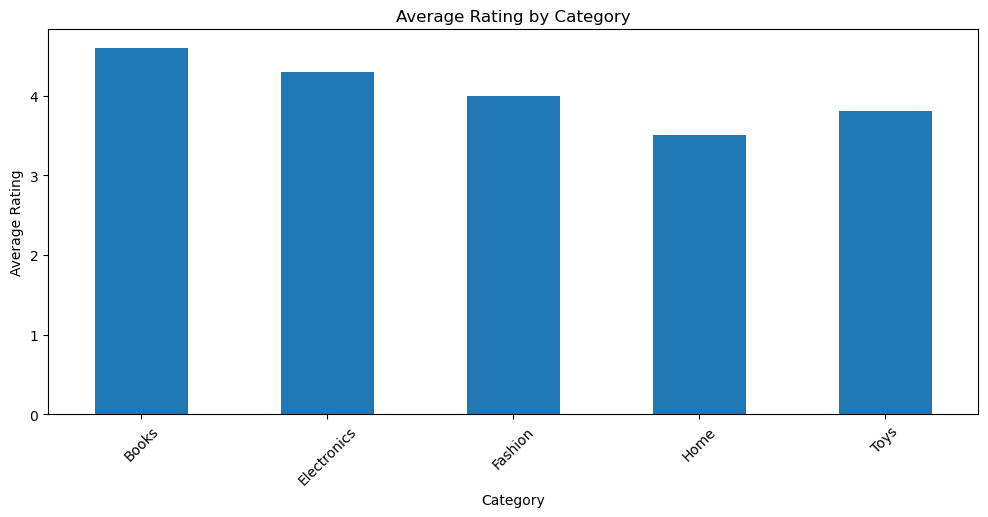

In [96]:
# Boxplot
# Category vs Ratings

plt.figure(figsize=(12,5))

avg_rating.plot(
    kind="bar"
)

plt.title("Average Rating by Category")

plt.xlabel("Category")

plt.ylabel("Average Rating")

plt.xticks(rotation=45)

plt.show()

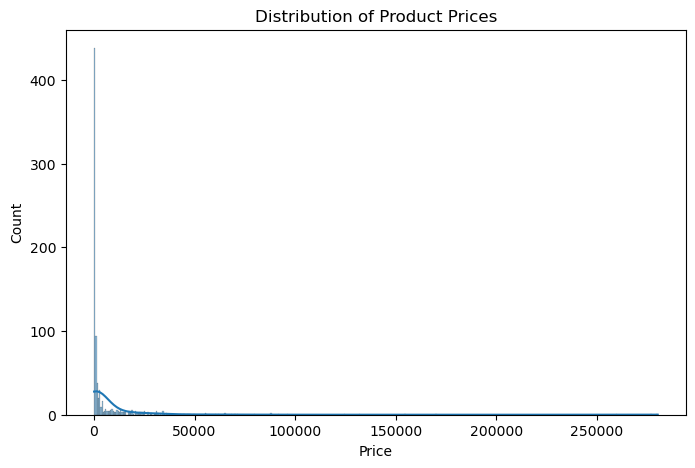

In [23]:
# Histogram

plt.figure(figsize=(8,5))

sns.histplot(df["Price"], kde=True)

plt.title("Distribution of Product Prices")

plt.show()

In [111]:
warn_singular=False

C:\Users\prasa\AppData\Local\Temp\ipykernel_15664\1246924712.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


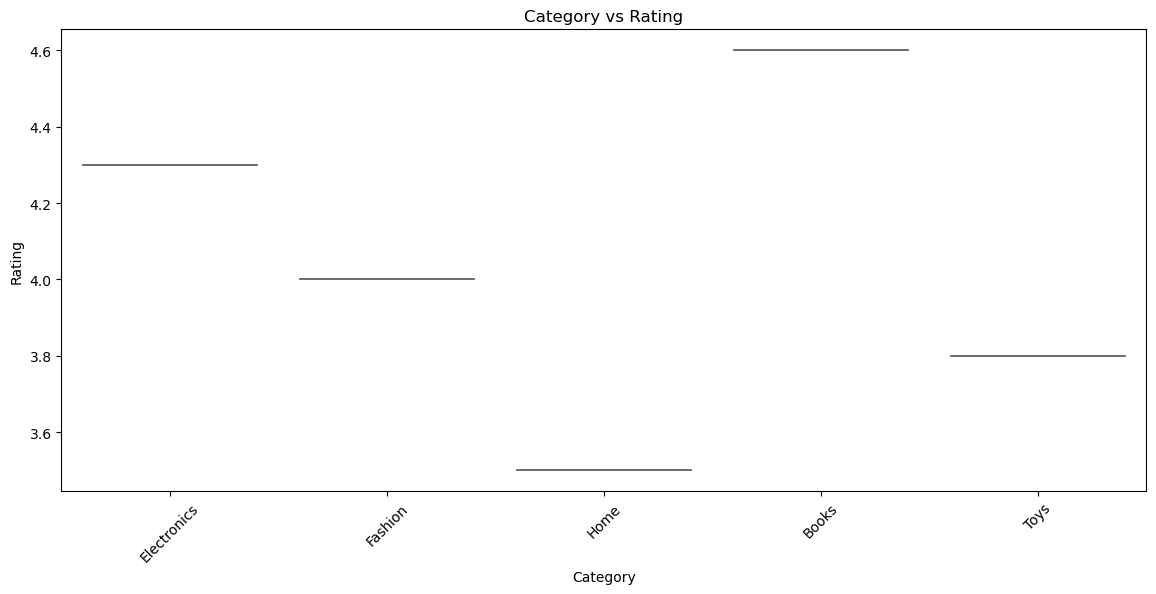

In [117]:
# Violin Plot


plt.figure(figsize=(14,6))

sns.violinplot(
    data=filtered_df,
    x="Category",
    y="Rating",
    palette="Set2"
)

plt.xticks(rotation=45)

plt.title("Category vs Rating")

plt.xlabel("Category")

plt.ylabel("Rating")

plt.show()

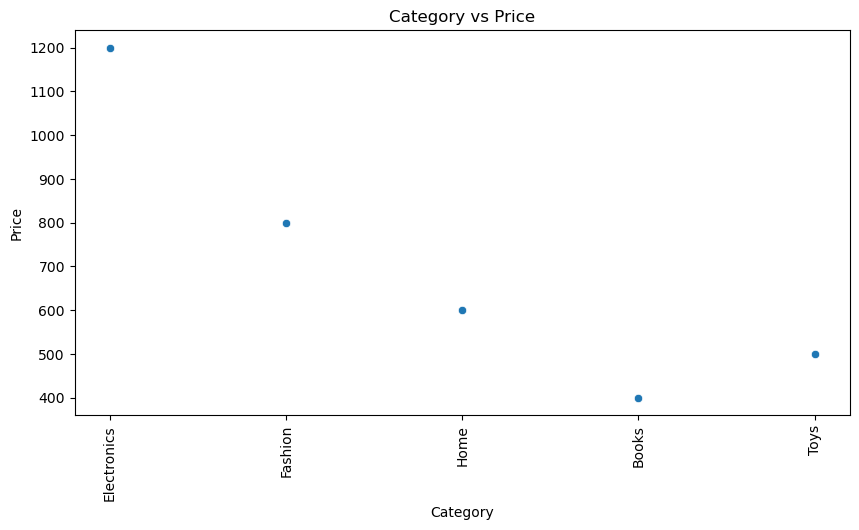

In [61]:
# Scatter Plot
# Category vs Price Scatter Plot

plt.figure(figsize=(10,5))

sns.scatterplot(
    x=df["Category"],
    y=df["Price"]
)

plt.xticks(rotation=90)

plt.title("Category vs Price")

plt.show()

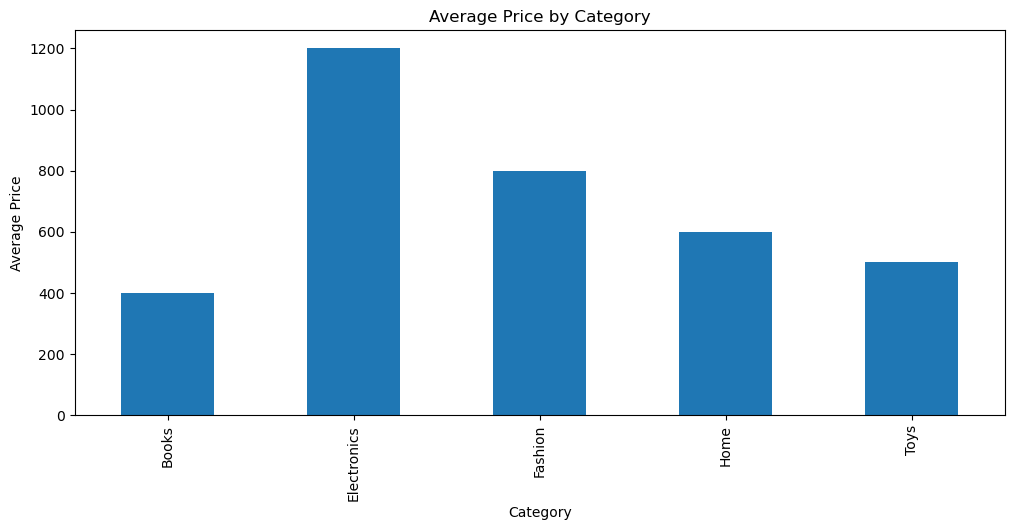

In [60]:
# Boxplot
# Category vs Price

avg_price = df.groupby("Category")["Price"].mean()

avg_price.plot(
    kind="bar",
    figsize=(12,5)
)

plt.title("Average Price by Category")

plt.ylabel("Average Price")

plt.show()

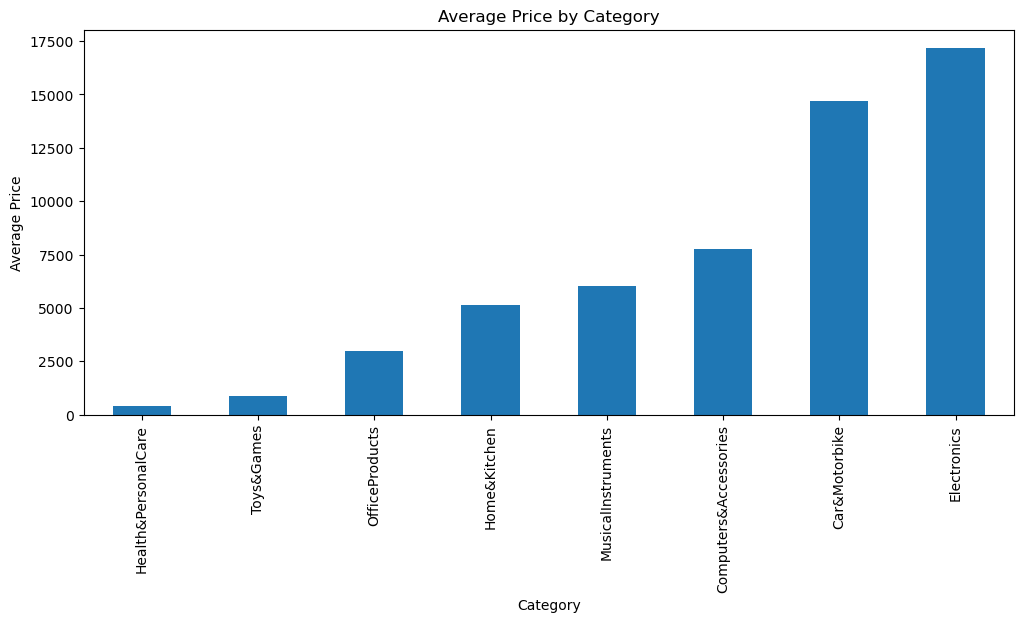

In [28]:
# Bar Plot

avg_price = df.groupby("Category")["Price"].mean().sort_values()

avg_price.plot(kind="bar", figsize=(12,5))

plt.title("Average Price by Category")

plt.ylabel("Average Price")

plt.show()

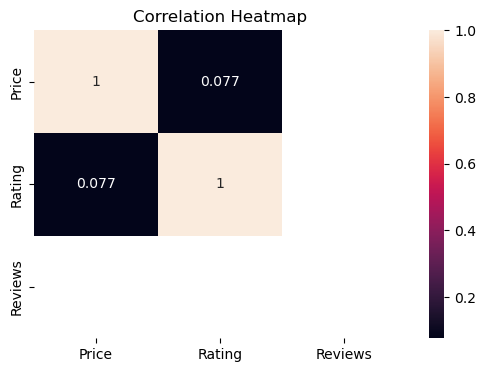

In [29]:
# Correlation Heatmap

corr = df[["Price","Rating","Reviews"]].corr()

plt.figure(figsize=(6,4))

sns.heatmap(corr, annot=True)

plt.title("Correlation Heatmap")

plt.show()

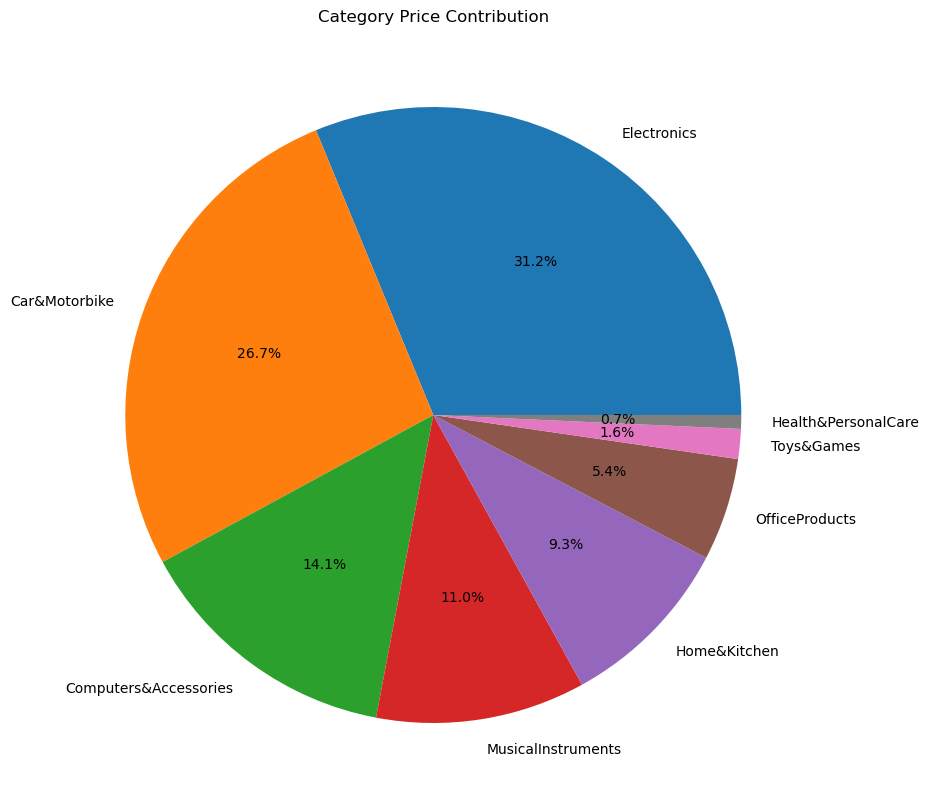

In [160]:
#Pie Chart
plt.figure(figsize=(10,10))

plt.pie(
    category_price,
    labels=category_price.index,
    autopct='%1.1f%%'
)

plt.title("Category Price Contribution")

plt.show()

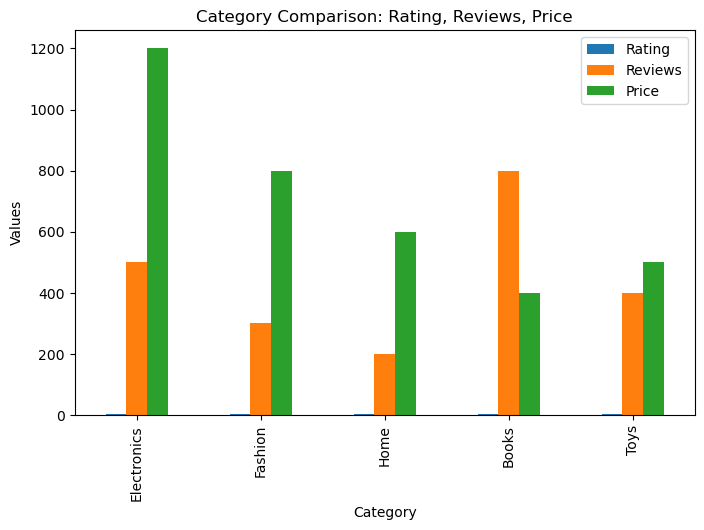

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

# Example data (replace with your actual DataFrame)
df = pd.DataFrame({
    'Category': ['Electronics', 'Fashion', 'Home', 'Books', 'Toys'],
    'Rating': [4.3, 4.0, 3.5, 4.6, 3.8],
    'Reviews': [500, 300, 200, 800, 400],
    'Price': [1200, 800, 600, 400, 500]
})

# Plot bar chart
df.plot(x='Category', y=['Rating', 'Reviews', 'Price'], kind='bar', figsize=(8,5))
plt.title("Category Comparison: Rating, Reviews, Price")
plt.ylabel("Values")
plt.show()


In [ ]:
#  Business Insights for Amazon EDA Project

In [ ]:
1. Product Categories with High Ratings 

Some categories consistently receive higher ratings from customers, showing strong customer satisfaction and product quality.

Business Insight:

Amazon can promote highly rated categories more aggressively to increase sales and customer trust.


2. Popular Categories Have More Reviews 

Categories with more customer reviews indicate higher customer engagement and demand.

Business Insight:

High-review categories represent popular market segments and can be prioritized for marketing campaigns and inventory expansion.


3. Medium-Priced Products Receive Better Ratings

Products in moderate price ranges often achieve better ratings compared to very cheap or very expensive products.

Business Insight:

Customers prefer products that provide balanced pricing and quality, helping sellers optimize pricing strategies.


4. Higher Reviews Increase Product Trust

Products with more reviews generally attract more customers because reviews improve trust and credibility.

Business Insight:

Encouraging customer reviews can improve product visibility and conversion rates.


5. Categories with Low Ratings Need Improvement

Some categories show lower average ratings and higher variation.

Business Insight:

These categories may require quality improvement, better customer support, or better seller management.



6. Data-Driven Decision Making

EDA helps identify:

*customer preferences
*trending categories
*pricing patterns
*product performance

Business Insight:
Businesses can use these insights for:

*pricing optimization
*inventory planning
*recommendation systems
*marketing strategies
*customer satisfaction improvement.